<a href="https://colab.research.google.com/github/MurphyKlein/CS4782_final_project/blob/main/notebook/PatchTST_LinProb_Weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PatchTST — Self-Supervised Pre-Training + Linear Probing
## Replicating Table 4 (Lin. Prob. column) — Weather Dataset
Paper: *A Time Series is Worth 64 Words: Long-Term Forecasting with Transformers* (ICLR 2023)


## 1  Install dependencies

In [ ]:
!pip install -q einops
print("Done")

Done


## 2  Imports

In [ ]:
import os, glob, copy, json, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
torch.manual_seed(2021)
np.random.seed(2021)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 3  Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4  Configuration

In [ ]:
class Config:
    # ── paths ──────────────────────────────────────────────────────────────
    project_path   = '/content/drive/MyDrive/DL_Final_Project'
    data_dir       = '/content/drive/MyDrive/DL_Final_Project/weather_data'
    checkpoint_dir = '/content/drive/MyDrive/DL_Final_Project/lin_prob_checkpoints'

    # ── sequence ───────────────────────────────────────────────────────────
    seq_len   = 512
    pred_lens = [96, 192, 336, 720]

    # ── patching (non-overlapping, as in SSL section of paper) ─────────────
    patch_len = 12
    stride    = 12     # non-overlapping  →  N ≈ 42 patches

    # ── transformer ────────────────────────────────────────────────────────
    d_model  = 128
    n_heads  = 16
    n_layers = 3
    d_ff     = 256
    dropout  = 0.2

    # ── pre-training ───────────────────────────────────────────────────────
    mask_ratio      = 0.40
    pretrain_epochs = 100
    pretrain_lr     = 1e-4
    pretrain_bs     = 128

    # ── linear probing ─────────────────────────────────────────────────────
    lp_epochs = 20
    lp_lr     = 1e-4
    lp_bs     = 128

    # ── early stopping ─────────────────────────────────────────────────────
    patience = 10

    # ── data split ─────────────────────────────────────────────────────────
    train_ratio = 0.7
    val_ratio   = 0.1

cfg = Config()
os.makedirs(cfg.checkpoint_dir, exist_ok=True)
print("Config ready. Checkpoints →", cfg.checkpoint_dir)

Config ready. Checkpoints → /content/drive/MyDrive/DL_Final_Project/lin_prob_checkpoints


## 5  Load & Combine Weather CSVs

In [ ]:
def load_and_combine_csvs(data_dir):
    files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))
    assert files, f"No CSV files found in {data_dir}"
    print(f"Found {len(files)} file(s):")
    for f in files:
        print(f"  {os.path.basename(f)}")

    dfs = []
    for f in files:
        # Added encoding='unicode_escape' to handle special characters
        df = pd.read_csv(f, encoding='unicode_escape')
        print(f"  Shape: {df.shape}")
        dfs.append(df)

    combined = pd.concat(dfs, ignore_index=True)

    # Sort by datetime column if present
    for col in combined.columns:
        if any(kw in col.lower() for kw in ('date', 'time')):
            try:
                combined[col] = pd.to_datetime(combined[col])
                combined = combined.sort_values(col).reset_index(drop=True)
                print(f"Sorted by '{col}'")
            except Exception:
                pass
            break

    # Keep only numeric features
    drop_cols = [c for c in combined.columns
                 if combined[c].dtype == object
                 or any(kw in c.lower() for kw in ('date', 'time'))]
    numeric = combined.drop(columns=drop_cols, errors='ignore') \
                      .select_dtypes(include=[np.number])

    save_path = os.path.join(cfg.project_path, 'weather_combined.csv')
    combined.to_csv(save_path, index=False)
    print(f"\nCombined shape : {numeric.shape}")
    print(f"Features ({numeric.shape[1]}): {list(numeric.columns)}")
    print(f"Saved combined CSV → {save_path}")
    return numeric.values.astype(np.float32)

data = load_and_combine_csvs(cfg.data_dir)
M = data.shape[1]
print(f"\nNumber of channels M = {M}")

Found 11 file(s):
  mpi_roof.csv
  mpi_roof_2020a.csv
  mpi_roof_2020b.csv
  mpi_roof_2021a.csv
  mpi_roof_2021b.csv
  mpi_roof_2022a.csv
  mpi_roof_2022b.csv
  mpi_roof_2023a.csv
  mpi_roof_2023b.csv
  mpi_roof_2024.csv
  mpi_roof_2025.csv
  Shape: (17403, 22)
  Shape: (26200, 22)
  Shape: (26496, 22)
  Shape: (26064, 22)
  Shape: (26496, 22)
  Shape: (26070, 22)
  Shape: (26415, 22)
  Shape: (26061, 22)
  Shape: (26639, 22)
  Shape: (52704, 22)
  Shape: (52560, 22)

Combined shape : (333108, 21)
Features (21): ['p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)', 'rain (mm)', 'raining (s)', 'SWDR (W/m²)', 'PAR (µmol/m²/s)', 'max. PAR (µmol/m²/s)', 'Tlog (degC)', 'CO2 (ppm)']
Saved combined CSV → /content/drive/MyDrive/DL_Final_Project/weather_combined.csv

Number of channels M = 21


## 6  Train / Val / Test splits + StandardScaler

In [ ]:
n       = len(data)
n_train = int(n * cfg.train_ratio)
n_val   = int(n * cfg.val_ratio)
n_test  = n - n_train - n_val

train_raw = data[:n_train]
val_raw   = data[n_train : n_train + n_val]
test_raw  = data[n_train + n_val :]

print(f"Total timesteps : {n}")
print(f"Train           : {n_train}")
print(f"Validation      : {n_val}")
print(f"Test            : {n_test}")

scaler   = StandardScaler()
train_sc = scaler.fit_transform(train_raw)
val_sc   = scaler.transform(val_raw)
test_sc  = scaler.transform(test_raw)

Total timesteps : 333108
Train           : 233175
Validation      : 33310
Test            : 66623


## 7  Dataset classes

In [ ]:
class PretrainDataset(Dataset):
    """Returns [M, L] windows for masked autoencoder pre-training."""
    def __init__(self, data, seq_len):
        self.data    = torch.FloatTensor(data)   # [T, M]
        self.seq_len = seq_len

    def __len__(self):
        return max(0, len(self.data) - self.seq_len + 1)

    def __getitem__(self, idx):
        return self.data[idx : idx + self.seq_len].T   # [M, L]


class ForecastDataset(Dataset):
    """Returns ([M, L], [M, pred_len]) pairs."""
    def __init__(self, data, seq_len, pred_len):
        self.data     = torch.FloatTensor(data)
        self.seq_len  = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return max(0, len(self.data) - self.seq_len - self.pred_len + 1)

    def __getitem__(self, idx):
        x = self.data[idx           : idx + self.seq_len]
        y = self.data[idx+self.seq_len : idx+self.seq_len+self.pred_len]
        return x.T, y.T   # [M, L],  [M, pred_len]


def pretrain_loaders():
    tr = DataLoader(PretrainDataset(train_sc, cfg.seq_len),
                    batch_size=cfg.pretrain_bs, shuffle=True,  drop_last=True)
    va = DataLoader(PretrainDataset(val_sc,   cfg.seq_len),
                    batch_size=cfg.pretrain_bs, shuffle=False, drop_last=False)
    return tr, va


def forecast_loaders(pred_len):
    kw = dict(drop_last=False)
    tr = DataLoader(ForecastDataset(train_sc, cfg.seq_len, pred_len),
                    batch_size=cfg.lp_bs, shuffle=True,  drop_last=True)
    va = DataLoader(ForecastDataset(val_sc,   cfg.seq_len, pred_len),
                    batch_size=cfg.lp_bs, shuffle=False, **kw)
    te = DataLoader(ForecastDataset(test_sc,  cfg.seq_len, pred_len),
                    batch_size=cfg.lp_bs, shuffle=False, **kw)
    return tr, va, te

print("Dataset classes ready.")

Dataset classes ready.


## 8  PatchTST model (backbone + pre-training head + forecasting head)

In [ ]:
# ── helpers ────────────────────────────────────────────────────────────────
def instance_norm(x, eps=1e-5):
    """x: [B, M, L] -> (x_norm, mean [B,M,1], std [B,M,1])"""
    mu  = x.mean(dim=-1, keepdim=True)
    std = x.std(dim=-1,  keepdim=True) + eps
    return (x - mu) / std, mu, std

def instance_denorm(x, mu, std):
    return x * std + mu


# ── Backbone ───────────────────────────────────────────────────────────────
class PatchTSTBackbone(nn.Module):
    """Channel-independent: patch projection + positional emb + Transformer."""

    def __init__(self, patch_len, stride, seq_len,
                 d_model, n_heads, n_layers, d_ff, dropout):
        super().__init__()
        self.patch_len   = patch_len
        self.stride      = stride
        # num_patches formula from the paper: floor((L-P)/S) + 2
        self.num_patches = (seq_len - patch_len) // stride + 2
        self.d_model     = d_model

        self.proj    = nn.Linear(patch_len, d_model)
        self.pos_emb = nn.Parameter(
            torch.zeros(1, self.num_patches, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        self.drop = nn.Dropout(dropout)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_ff, dropout=dropout,
            batch_first=True, norm_first=False)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

    def patchify(self, x):
        """x: [N, L] -> patches [N, num_patches, patch_len]"""
        pad  = x[:, -1:].expand(-1, self.stride)
        x_p  = torch.cat([x, pad], dim=1)
        return x_p.unfold(1, self.patch_len, self.stride)   # [N, NP, P]

    def forward(self, x):
        """x: [B*M, L] -> [B*M, num_patches, d_model]"""
        z = self.proj(self.patchify(x)) + self.pos_emb
        z = self.drop(z)
        return self.encoder(z)


# ── Pre-training (Masked Autoencoder) ─────────────────────────────────────
class PatchTSTMaskedAE(nn.Module):
    def __init__(self, backbone, mask_ratio):
        super().__init__()
        self.backbone   = backbone
        self.mask_ratio = mask_ratio
        self.head       = nn.Linear(backbone.d_model, backbone.patch_len)

    def forward(self, x):
        """x: [B, M, L]  ->  scalar MSE loss on masked patches"""
        B, M, L = x.shape
        x_norm, _, _ = instance_norm(x)
        bm = B * M
        xf = x_norm.reshape(bm, L)

        patches = self.backbone.patchify(xf)     # [B*M, N, P]
        N, P    = patches.shape[1], patches.shape[2]

        n_mask = int(N * self.mask_ratio)
        noise  = torch.rand(bm, N, device=x.device)
        ids    = torch.argsort(noise, dim=1)
        bool_mask = torch.zeros(bm, N, dtype=torch.bool, device=x.device)
        bool_mask.scatter_(1, ids[:, :n_mask], True)

        p_in = patches.clone()
        p_in[bool_mask] = 0.0

        z    = self.backbone.proj(p_in) + self.backbone.pos_emb
        z    = self.backbone.drop(z)
        z    = self.backbone.encoder(z)
        pred = self.head(z)

        loss = ((pred - patches) ** 2)[bool_mask].mean()
        return loss


# ── Forecasting head (linear probe / fine-tune) ───────────────────────────
class PatchTSTForecast(nn.Module):
    def __init__(self, backbone, pred_len, freeze_backbone=True):
        super().__init__()
        self.backbone = backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad_(False)
        flat_dim = backbone.num_patches * backbone.d_model
        self.head = nn.Linear(flat_dim, pred_len)

    def forward(self, x, return_stats=False):
        """x: [B, M, L] -> [B, M, pred_len]  (in instance-normalized space)"""
        B, M, L = x.shape
        x_norm, mu, std = instance_norm(x)
        z    = self.backbone(x_norm.reshape(B*M, L))   # [B*M, N, d]
        pred = self.head(z.flatten(1))                 # [B*M, pred_len]
        pred = pred.reshape(B, M, -1)                  # [B, M, pred_len]
        if return_stats:
            return pred, mu, std   # caller handles denorm
        return pred

print(f"Model classes ready.  backbone num_patches = "
      f"{(cfg.seq_len - cfg.patch_len) // cfg.stride + 2}")

Model classes ready.  backbone num_patches = 43


## 9  Early Stopping helper

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, delta=1e-6, path='checkpoint.pt'):
        self.patience = patience
        self.delta    = delta
        self.path     = path
        self.best     = np.inf
        self.counter  = 0
        self.stop     = False

    def __call__(self, val_loss, model):
        if val_loss < self.best - self.delta:
            self.best    = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            return True          # saved
        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False

## 10  Phase 1 — Self-Supervised Pre-Training (Masked Autoencoder)

PHASE 1  –  SELF-SUPERVISED PRE-TRAINING
Epoch   1/100  train=0.950653  val=0.849508  lr=1.00e-04  [126s] ✓
Epoch  10/100  train=0.208055  val=0.213880  lr=9.76e-05  [1243s]
Epoch  20/100  train=0.197552  val=0.216488  lr=9.05e-05  [2487s]

Early stopping at epoch 23  (best val = 0.209218)

Loaded best pre-trained backbone.


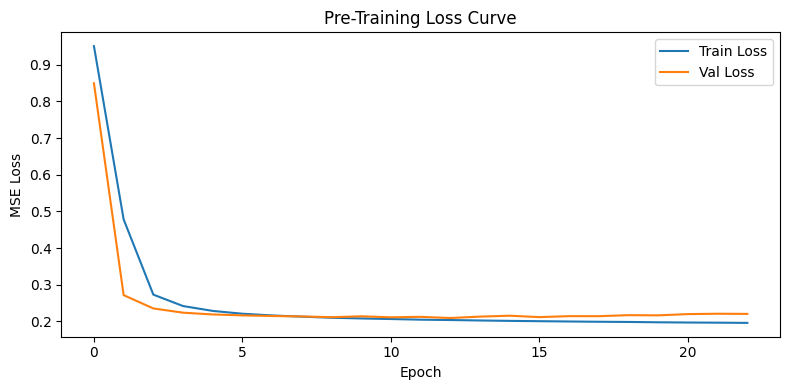

In [ ]:
print("=" * 65)
print("PHASE 1  –  SELF-SUPERVISED PRE-TRAINING")
print("=" * 65)

backbone = PatchTSTBackbone(
    patch_len = cfg.patch_len,
    stride    = cfg.stride,
    seq_len   = cfg.seq_len,
    d_model   = cfg.d_model,
    n_heads   = cfg.n_heads,
    n_layers  = cfg.n_layers,
    d_ff      = cfg.d_ff,
    dropout   = cfg.dropout,
).to(device)

mae_model = PatchTSTMaskedAE(backbone, cfg.mask_ratio).to(device)

pt_ckpt = os.path.join(cfg.checkpoint_dir, 'pretrained_backbone.pt')
es_pt   = EarlyStopping(patience=cfg.patience, path=pt_ckpt)

opt_pt  = optim.Adam(mae_model.parameters(), lr=cfg.pretrain_lr)
sch_pt  = optim.lr_scheduler.CosineAnnealingLR(opt_pt, T_max=cfg.pretrain_epochs)

tr_loader, va_loader = pretrain_loaders()

pt_train_losses, pt_val_losses = [], []
start = __import__('time').time()

for epoch in range(1, cfg.pretrain_epochs + 1):
    # --- train ---
    mae_model.train()
    tr_loss = 0.0
    for xb in tr_loader:
        xb = xb.to(device)
        opt_pt.zero_grad()
        loss = mae_model(xb)
        loss.backward()
        nn.utils.clip_grad_norm_(mae_model.parameters(), 1.0)
        opt_pt.step()
        tr_loss += loss.item()
    tr_loss /= len(tr_loader)

    # --- val ---
    mae_model.eval()
    va_loss = 0.0
    with torch.no_grad():
        for xb in va_loader:
            va_loss += mae_model(xb.to(device)).item()
    va_loss /= len(va_loader)

    sch_pt.step()
    pt_train_losses.append(tr_loss)
    pt_val_losses.append(va_loss)

    saved = es_pt(va_loss, backbone)
    flag  = " ✓" if saved else ""

    if epoch % 10 == 0 or epoch == 1:
        elapsed = __import__('time').time() - start
        print(f"Epoch {epoch:3d}/{cfg.pretrain_epochs}  "
              f"train={tr_loss:.6f}  val={va_loss:.6f}  "
              f"lr={sch_pt.get_last_lr()[0]:.2e}  "
              f"[{elapsed:.0f}s]{flag}")

    if es_pt.stop:
        print(f"\nEarly stopping at epoch {epoch}  "
              f"(best val = {es_pt.best:.6f})")
        break

# Load best backbone
backbone.load_state_dict(torch.load(pt_ckpt, map_location=device))
print("\nLoaded best pre-trained backbone.")

# Plot
plt.figure(figsize=(8, 4))
plt.plot(pt_train_losses, label='Train Loss')
plt.plot(pt_val_losses,   label='Val Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('Pre-Training Loss Curve')
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(cfg.project_path, 'pretrain_loss.png'), dpi=100)
plt.show()

## 11  Phase 2 — Linear Probing (frozen backbone, train head only)

PHASE 2  –  LINEAR PROBING

──────────────────────────────────────────────────
pred_len = 96
──────────────────────────────────────────────────
Trainable params: 528,480  (head only)
  Epoch  1/20  train=0.395235  val=0.363750  lr=3.46e-04 ✓
  Epoch  2/20  train=0.383841  val=0.360428  lr=2.74e-04 ✓
  Epoch  3/20  train=0.382248  val=0.357509  lr=2.07e-04 ✓
  Epoch  4/20  train=0.379724  val=0.364251  lr=1.47e-04
  Epoch  5/20  train=0.378938  val=0.365748  lr=9.64e-05
  Epoch  6/20  train=0.378227  val=0.362892  lr=5.54e-05
  Epoch  7/20  train=0.377932  val=0.370404  lr=2.54e-05
  Epoch  8/20  train=0.378110  val=0.357002  lr=7.15e-06 ✓
  Epoch  9/20  train=0.376696  val=0.363764  lr=1.00e-06
  Epoch 10/20  train=0.376996  val=0.360730  lr=7.15e-06
  Epoch 11/20  train=0.376721  val=0.380114  lr=2.54e-05
  Epoch 12/20  train=0.375402  val=0.363098  lr=5.54e-05
  Epoch 13/20  train=0.374837  val=0.355739  lr=9.64e-05 ✓
  Epoch 14/20  train=0.374625  val=0.357715  lr=1.47e-04
  Epoch 1

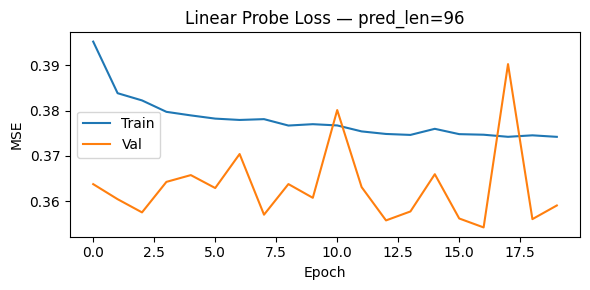


──────────────────────────────────────────────────
pred_len = 192
──────────────────────────────────────────────────
Trainable params: 1,056,960  (head only)
  Epoch  1/20  train=0.459808  val=0.426105  lr=6.55e-04 ✓
  Epoch  2/20  train=0.449932  val=0.422014  lr=7.27e-04 ✓
  Epoch  3/20  train=0.447113  val=0.424783  lr=7.94e-04
  Epoch  4/20  train=0.446578  val=0.427971  lr=8.54e-04
  Epoch  5/20  train=0.443585  val=0.416006  lr=9.05e-04 ✓
  Epoch  6/20  train=0.443930  val=0.412334  lr=9.46e-04 ✓
  Epoch  7/20  train=0.443598  val=0.419485  lr=9.76e-04
  Epoch  8/20  train=0.443264  val=0.427568  lr=9.94e-04
  Epoch  9/20  train=0.441063  val=0.415285  lr=1.00e-03
  Epoch 10/20  train=0.440875  val=0.410746  lr=9.94e-04 ✓
  Epoch 11/20  train=0.442355  val=0.420888  lr=9.76e-04
  Epoch 12/20  train=0.439607  val=0.418674  lr=9.46e-04
  Epoch 13/20  train=0.438859  val=0.416792  lr=9.05e-04
  Epoch 14/20  train=0.439491  val=0.419747  lr=8.54e-04
  Epoch 15/20  train=0.439130  va

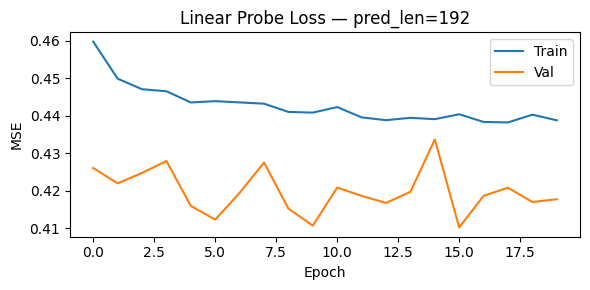


──────────────────────────────────────────────────
pred_len = 336
──────────────────────────────────────────────────
Trainable params: 1,849,680  (head only)
  Epoch  1/20  train=0.523996  val=0.479748  lr=3.46e-04 ✓
  Epoch  2/20  train=0.513684  val=0.485463  lr=2.74e-04
  Epoch  3/20  train=0.509661  val=0.478278  lr=2.07e-04 ✓
  Epoch  4/20  train=0.508941  val=0.474589  lr=1.47e-04 ✓
  Epoch  5/20  train=0.510117  val=0.469202  lr=9.64e-05 ✓
  Epoch  6/20  train=0.507692  val=0.470886  lr=5.54e-05
  Epoch  7/20  train=0.508941  val=0.487614  lr=2.54e-05
  Epoch  8/20  train=0.508155  val=0.478734  lr=7.15e-06
  Epoch  9/20  train=0.505443  val=0.471376  lr=1.00e-06
  Epoch 10/20  train=0.505688  val=0.541500  lr=7.15e-06
  Epoch 11/20  train=0.504802  val=0.463932  lr=2.54e-05 ✓
  Epoch 12/20  train=0.503746  val=0.476397  lr=5.54e-05
  Epoch 13/20  train=0.504398  val=0.494405  lr=9.64e-05
  Epoch 14/20  train=0.503918  val=0.463774  lr=1.47e-04 ✓
  Epoch 15/20  train=0.504066  

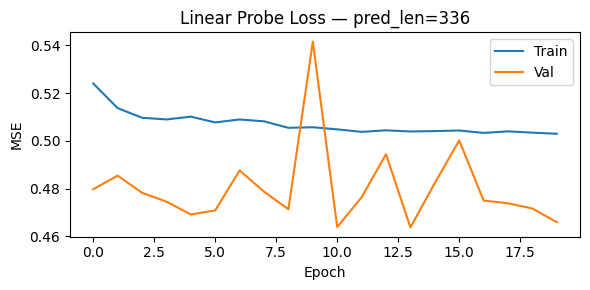


──────────────────────────────────────────────────
pred_len = 720
──────────────────────────────────────────────────
Trainable params: 3,963,600  (head only)
  Epoch  1/20  train=0.605398  val=0.567632  lr=6.55e-04 ✓
  Epoch  2/20  train=0.593046  val=0.556737  lr=7.27e-04 ✓
  Epoch  3/20  train=0.592829  val=0.571619  lr=7.94e-04
  Epoch  4/20  train=0.589917  val=0.555194  lr=8.54e-04 ✓
  Epoch  5/20  train=0.590329  val=0.565678  lr=9.05e-04
  Epoch  6/20  train=0.586022  val=0.552433  lr=9.46e-04 ✓
  Epoch  7/20  train=0.589079  val=0.545634  lr=9.76e-04 ✓
  Epoch  8/20  train=0.587111  val=0.563145  lr=9.94e-04
  Epoch  9/20  train=0.587435  val=0.547975  lr=1.00e-03
  Epoch 10/20  train=0.586502  val=0.548974  lr=9.94e-04
  Epoch 11/20  train=0.586767  val=0.580726  lr=9.76e-04
  Epoch 12/20  train=0.585026  val=0.543532  lr=9.46e-04 ✓
  Epoch 13/20  train=0.584906  val=0.555405  lr=9.05e-04
  Epoch 14/20  train=0.583537  val=0.554396  lr=8.54e-04
  Epoch 15/20  train=0.586239  

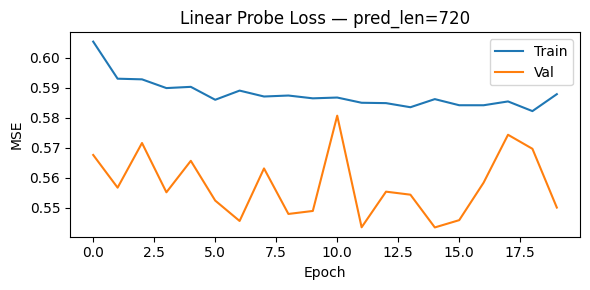

In [ ]:
# Paper Table-4 Lin. Prob. results for Weather
paper_lp = {
    96:  {'MSE': 0.158, 'MAE': 0.209},
    192: {'MSE': 0.203, 'MAE': 0.249},
    336: {'MSE': 0.251, 'MAE': 0.285},
    720: {'MSE': 0.321, 'MAE': 0.336},
}

our_results = {}

print("=" * 65)
print("PHASE 2  –  LINEAR PROBING")
print("=" * 65)

for pred_len in cfg.pred_lens:
    print(f"\n{'─'*50}")
    print(f"pred_len = {pred_len}")
    print(f"{'─'*50}")

    bb = copy.deepcopy(backbone)
    model = PatchTSTForecast(bb, pred_len=pred_len, freeze_backbone=True).to(device)

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable params: {n_trainable:,}  (head only)")

    lp_ckpt = os.path.join(cfg.checkpoint_dir, f'linprob_T{pred_len}.pt')
    es      = EarlyStopping(patience=cfg.patience, path=lp_ckpt)

    trainable = [p for p in model.parameters() if p.requires_grad]
    opt = optim.Adam(trainable, lr=1e-3)
    # sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.lp_epochs, eta_min=1e-6)
    criterion = nn.MSELoss()

    tr_loader, va_loader, te_loader = forecast_loaders(pred_len)
    lp_tr_losses, lp_va_losses = [], []

    for epoch in range(1, cfg.lp_epochs + 1):
        # train
        model.train()
        model.backbone.eval()   # keep frozen backbone deterministic (no dropout)
        tr_loss = 0.0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred_norm, mu, std = model(xb, return_stats=True)
            pred = instance_denorm(pred_norm, mu, std)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            opt.step()
            tr_loss += loss.item()
        tr_loss /= len(tr_loader)

        # val
        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for xb, yb in va_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred_norm, mu, std = model(xb, return_stats=True)
                pred = instance_denorm(pred_norm, mu, std)
                va_loss += criterion(pred, yb).item()
        va_loss /= len(va_loader)

        sch.step()
        lp_tr_losses.append(tr_loss)
        lp_va_losses.append(va_loss)

        saved = es(va_loss, model)
        flag  = " ✓" if saved else ""
        print(f"  Epoch {epoch:2d}/{cfg.lp_epochs}  "
              f"train={tr_loss:.6f}  val={va_loss:.6f}  "
              f"lr={sch.get_last_lr()[0]:.2e}{flag}")

        if es.stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    # load best and evaluate on test
    model.load_state_dict(torch.load(lp_ckpt, map_location=device))
    model.eval()

    all_preds, all_trues = [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            xb = xb.to(device)
            pred_norm, mu, std = model(xb, return_stats=True)
            pred = instance_denorm(pred_norm, mu, std).cpu().numpy()
            all_preds.append(pred)
            all_trues.append(yb.numpy())

    preds = np.concatenate(all_preds, axis=0)
    trues = np.concatenate(all_trues, axis=0)

    mse = float(np.mean((preds - trues) ** 2))
    mae = float(np.mean(np.abs(preds - trues)))

    our_results[pred_len] = {'MSE': round(mse, 4), 'MAE': round(mae, 4)}

    p = paper_lp[pred_len]
    print(f"\n  TEST  MSE = {mse:.4f}  (paper: {p['MSE']:.3f},  Δ={mse-p['MSE']:+.4f})")
    print(f"        MAE = {mae:.4f}  (paper: {p['MAE']:.3f},  Δ={mae-p['MAE']:+.4f})")

    plt.figure(figsize=(6, 3))
    plt.plot(lp_tr_losses, label='Train')
    plt.plot(lp_va_losses, label='Val')
    plt.xlabel('Epoch'); plt.ylabel('MSE')
    plt.title(f'Linear Probe Loss — pred_len={pred_len}')
    plt.legend(); plt.tight_layout()
    plt.savefig(os.path.join(cfg.project_path, f'linprob_T{pred_len}_loss.png'), dpi=100)
    plt.show()

## 12  Results — comparison with paper


RESULTS COMPARISON  –  Weather Dataset, Lin. Prob., Table 4 of paper
     T |  Paper MSE  Paper MAE |   Our MSE   Our MAE |     ΔMSE     ΔMAE
------------------------------------------------------------------------
    96 |      0.158      0.209 |    0.2673    0.2816 |  +0.1093  +0.0726
   192 |      0.203      0.249 |    0.3148    0.3266 |  +0.1118  +0.0776
   336 |      0.251      0.285 |    0.3652    0.3627 |  +0.1142  +0.0777
   720 |      0.321      0.336 |    0.4435    0.4154 |  +0.1225  +0.0794


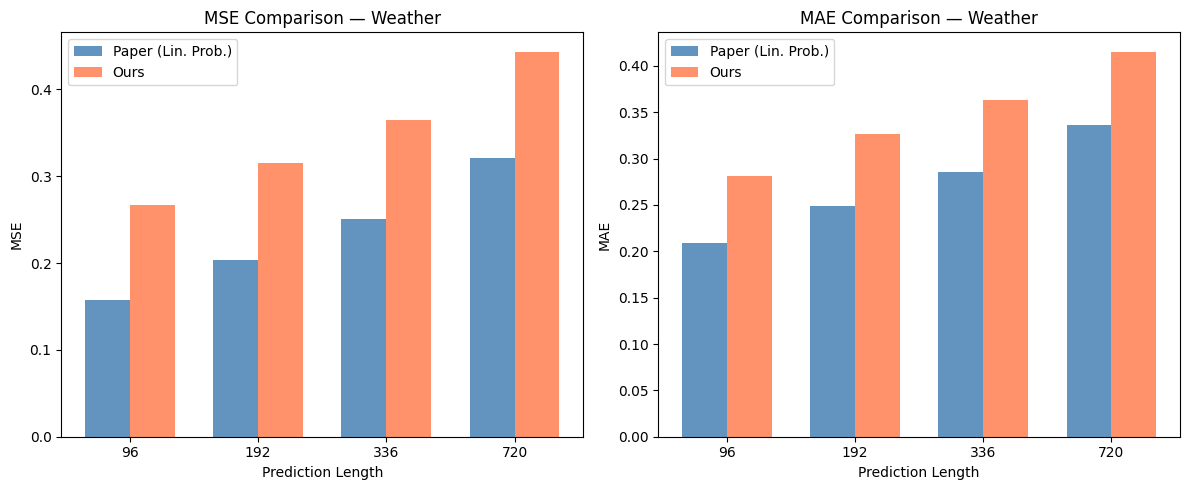


Figure saved → /content/drive/MyDrive/DL_Final_Project/results_comparison.png
Results JSON saved → /content/drive/MyDrive/DL_Final_Project/linprob_results.json


In [ ]:
print("\n" + "=" * 72)
print("RESULTS COMPARISON  –  Weather Dataset, Lin. Prob., Table 4 of paper")
print("=" * 72)
hdr = f"{'T':>6} | {'Paper MSE':>10} {'Paper MAE':>10} | {'Our MSE':>9} {'Our MAE':>9} | {'ΔMSE':>8} {'ΔMAE':>8}"
print(hdr)
print("-" * 72)
for T in cfg.pred_lens:
    p = paper_lp[T]
    o = our_results[T]
    print(f"{T:>6} | {p['MSE']:>10.3f} {p['MAE']:>10.3f} | "
          f"{o['MSE']:>9.4f} {o['MAE']:>9.4f} | "
          f"{o['MSE']-p['MSE']:>+8.4f} {o['MAE']-p['MAE']:>+8.4f}")

# ── bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x  = np.arange(len(cfg.pred_lens))
w  = 0.35
xl = [str(T) for T in cfg.pred_lens]

p_mses = [paper_lp[T]['MSE'] for T in cfg.pred_lens]
p_maes = [paper_lp[T]['MAE'] for T in cfg.pred_lens]
o_mses = [our_results[T]['MSE'] for T in cfg.pred_lens]
o_maes = [our_results[T]['MAE'] for T in cfg.pred_lens]

for ax, paper_vals, our_vals, metric in zip(
        axes, [p_mses, p_maes], [o_mses, o_maes], ['MSE', 'MAE']):
    ax.bar(x - w/2, paper_vals, w, label='Paper (Lin. Prob.)', alpha=0.85, color='steelblue')
    ax.bar(x + w/2, our_vals,   w, label='Ours',               alpha=0.85, color='coral')
    ax.set_xticks(x); ax.set_xticklabels(xl)
    ax.set_xlabel('Prediction Length'); ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison — Weather')
    ax.legend()

plt.tight_layout()
fig_path = os.path.join(cfg.project_path, 'results_comparison.png')
plt.savefig(fig_path, dpi=120)
plt.show()
print(f"\nFigure saved → {fig_path}")

# ── save JSON ──────────────────────────────────────────────────────────────
results = {'paper_lin_prob': {str(k): v for k, v in paper_lp.items()},
           'our_results':    {str(k): v for k, v in our_results.items()}}
rpath = os.path.join(cfg.project_path, 'linprob_results.json')
with open(rpath, 'w') as f:
    json.dump(results, f, indent=2)
print(f"Results JSON saved → {rpath}")